In [24]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc

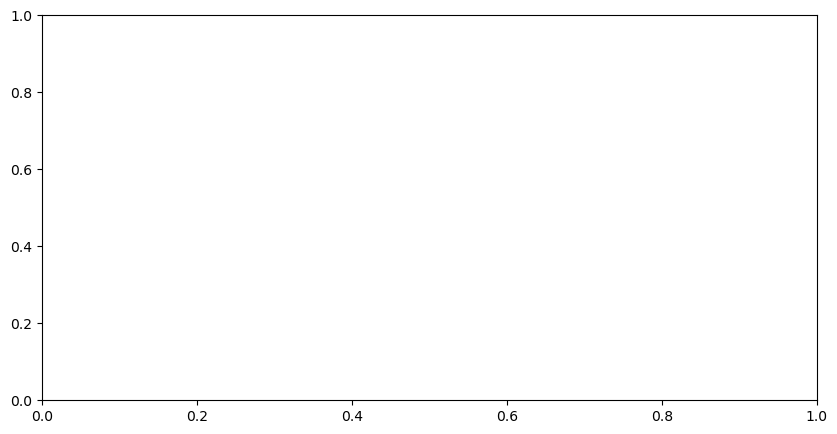

In [25]:
fig_roc, ax_roc = plt.subplots(figsize=(10, 5))

/tmp/ipykernel_506335/240889897.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_506335/240889897.py:60: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_506335/240889897.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_506335/240889897.py:60: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


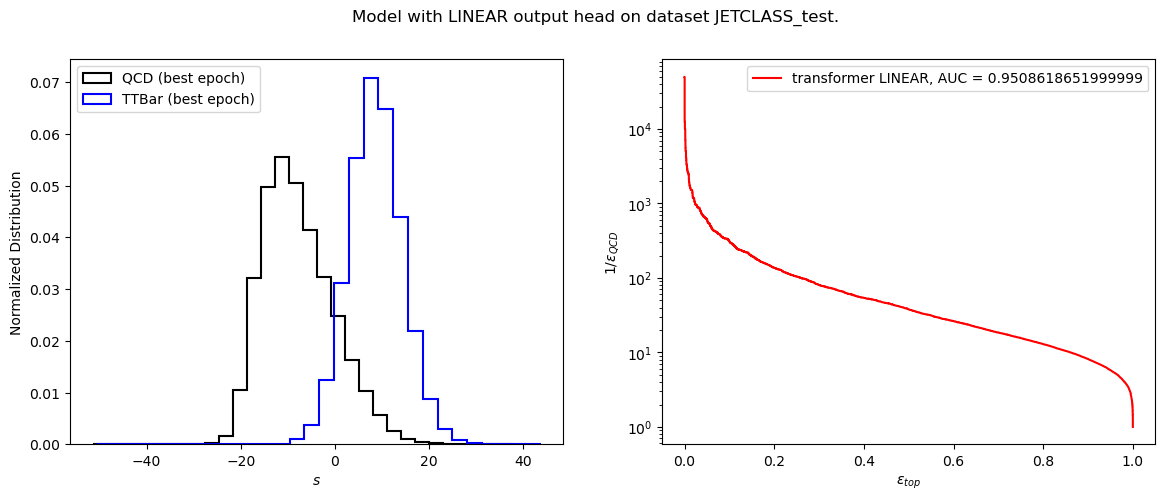

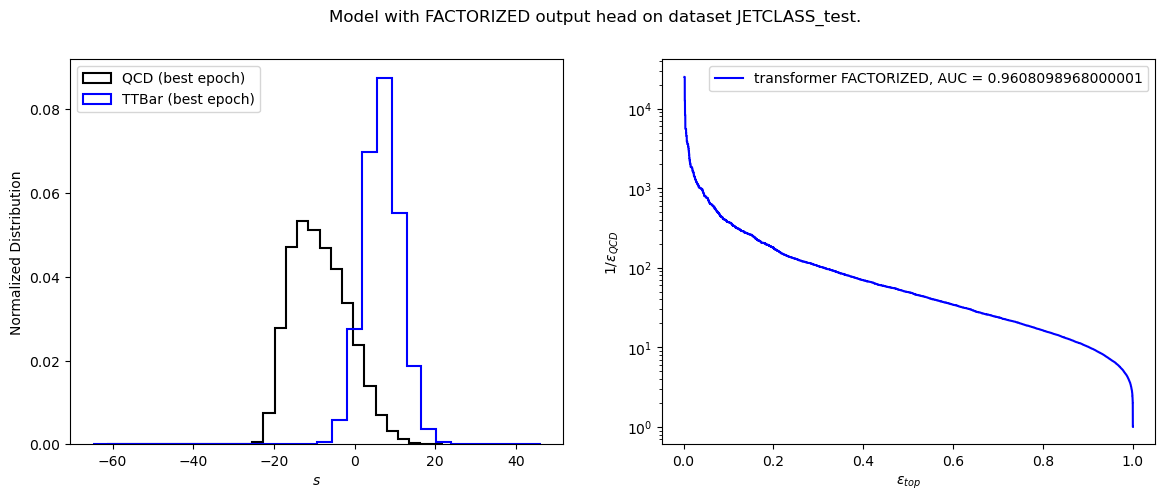

In [26]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAG = "test"

outputmodes = ["LINEAR", "FACTORIZED"]

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
colors_outputmodes = ["red", "blue"]

for j in range(len(outputmodes)):
        
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    bins = 60

    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[1]}_{outputmodes[j]}_{classes[i]}_{TAG}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[0]}_{outputmodes[j]}_{classes[i]}_{TAG}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        color = colors_outputmodes[j],
        label = f"transformer {outputmodes[j]}, AUC = {roc_auc}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                color = colors_outputmodes[j],
                label = f"{DATASET} {TAG} {outputmodes[j]}, AUC = {roc_auc}")

    fig.suptitle(f"Model with {outputmodes[j]} output head on dataset {DATASET}_{TAG}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


/tmp/ipykernel_506335/890899207.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_506335/890899207.py:60: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_506335/890899207.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_506335/890899207.py:60: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


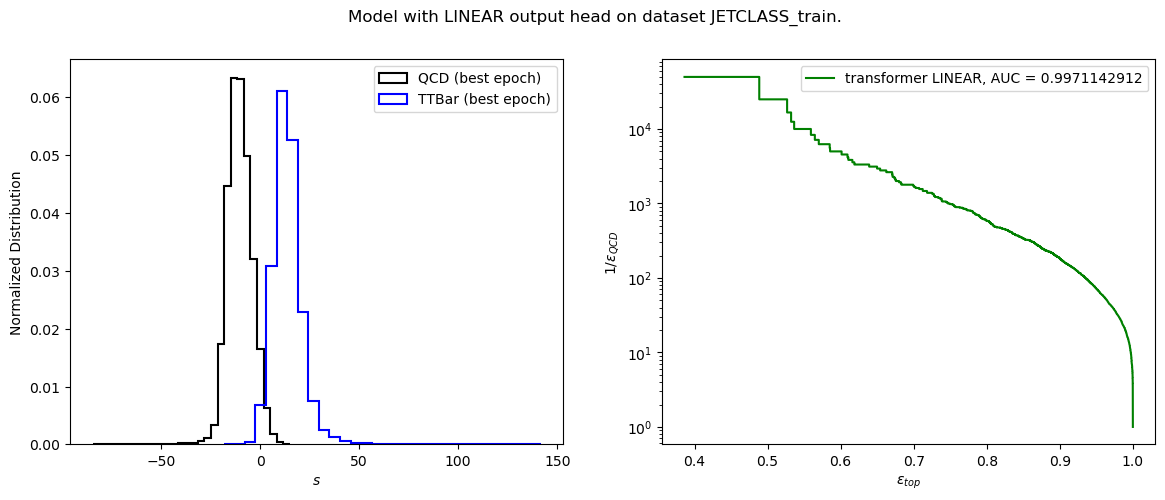

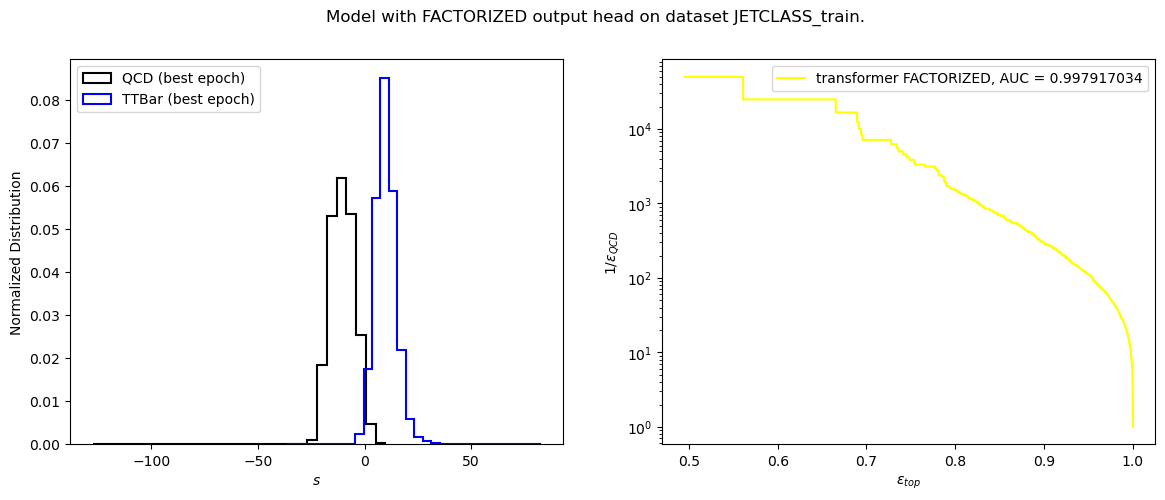

In [ ]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAG = "train"

outputmodes = ["LINEAR", "FACTORIZED"]

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
colors_outputmodes = ["green", "midnightblue"]

for j in range(len(outputmodes)):
        
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    bins = 60

    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[1]}_{outputmodes[j]}_{classes[i]}_{TAG}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[0]}_{outputmodes[j]}_{classes[i]}_{TAG}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        color = colors_outputmodes[j],
        label = f"transformer {outputmodes[j]}, AUC = {roc_auc}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                color = colors_outputmodes[j],
                label = f"{DATASET} {TAG} {outputmodes[j]}, AUC = {roc_auc}")

    fig.suptitle(f"Model with {outputmodes[j]} output head on dataset {DATASET}_{TAG}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


/tmp/ipykernel_506335/182908722.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_506335/182908722.py:60: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


/tmp/ipykernel_506335/182908722.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,


ValueError: 'light_blue' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

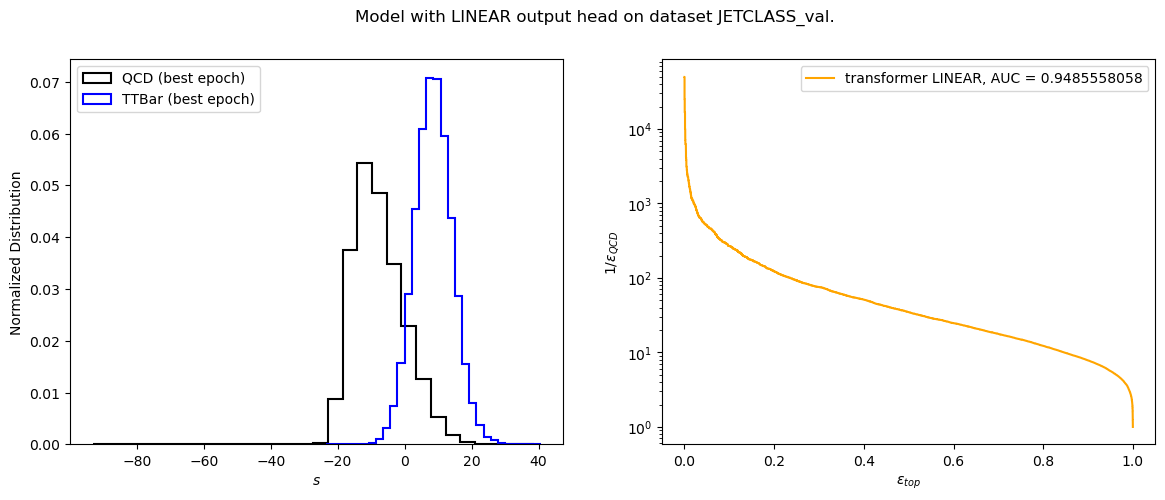

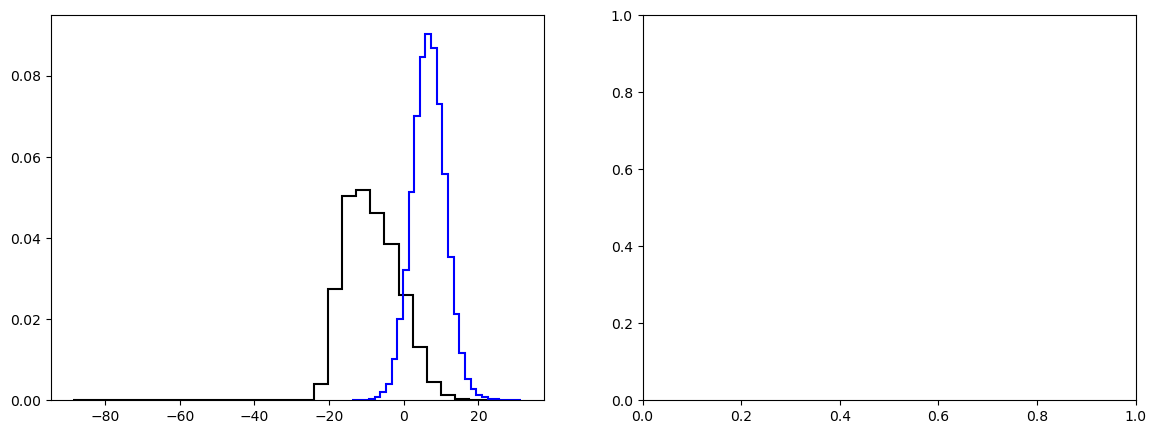

In [ ]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAG = "val"

outputmodes = ["LINEAR", "FACTORIZED"]

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
colors_outputmodes = ["orange", "darkolivegreen"]

for j in range(len(outputmodes)):
        
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    bins = 60

    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[1]}_{outputmodes[j]}_{classes[i]}_{TAG}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[0]}_{outputmodes[j]}_{classes[i]}_{TAG}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        color = colors_outputmodes[j],
        label = f"transformer {outputmodes[j]}, AUC = {roc_auc}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                color = colors_outputmodes[j],
                label = f"{DATASET} {TAG} {outputmodes[j]}, AUC = {roc_auc}")

    fig.suptitle(f"Model with {outputmodes[j]} output head on dataset {DATASET}_{TAG}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


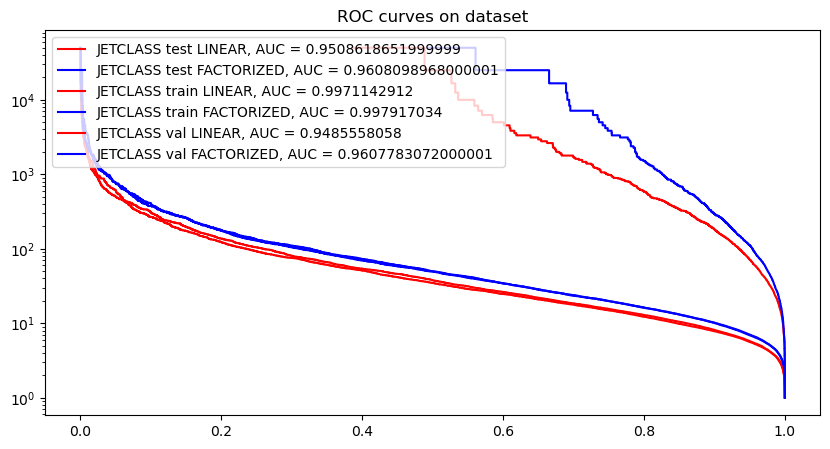

In [ ]:
ax_roc.set_title(f"ROC curves on dataset")
ax_roc.legend()
ax_roc.set_yscale("log")

from IPython.display import display
display(fig_roc)